# D210 Performance Assessment

## Part 1: Interactive Data Dashboard

### A. Provide a copy of your interactive Tableau dashboard to support executive decision-making. Your dashboard must be accessible to users with colorblindness, and must include the components in *each* of the following bullet points:

#### - Data integrated from *both* chosen data sets
#### - Four different data representations to summarize the data or display trends
#### - Two different interactive controls that allow the user to modify the presentation of data
#### - Two different metrics or key performance indicators computed using data from *both* chosen data sets

The interactive Tableau dashboard is available at the below link:

https://public.tableau.com/app/profile/matthew.helbig/viz/D210PerformanceAssessment_17081151912580/Story1#1

#### 1. Provide *both* data sets that serve as the data source for the dashboard.

The external data set chosen for this performance assessment can be found at https://www.kaggle.com/datasets/dubradave/hospital-readmissions/. This file is also uploaded as part of this submission as "hospital_readmissions.csv".

The WGU data set used for this performance assessment is the Medical Data data set. This file is uploaded as part of this submission as "medical_clean.csv"

In addition to the above raw data files, cleaned/combined versions of the files are also uploaded as part of this submission. The files "cleaned_medical_data.csv", "cleaned_external_data.csv", and "cleaned_combined_data.csv" were all created in Python as part of data cleaning so that the data could be properly read into Tableau. Both data sets serve as the data source for the dashboard, however, in order to read the data into Tableau more easily, they have been combined into a dataset called "cleaned_combined_data.csv". The "cleaned_combined_data.csv" file is the only file used in Tableau, however for the sake of completion and transparency, the "cleaned_medical_data.csv" and "cleaned_external_data.csv" files are still included.

The data cleaning Python code can be found below:

In [34]:
#Import libraries
import pandas as pd

In [35]:
#Read in file
file = "hospital_readmissions.csv"
external_data = pd.read_csv(file)

In [36]:
#Check duplicates
print(external_data.duplicated().value_counts())

False    25000
Name: count, dtype: int64


In [37]:
#Check missing values
print(external_data.isnull().sum())

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [38]:
#Look at values for desired columns to see if they need re-encoding to work with WGU data
print(external_data.age.value_counts())

age
[70-80)     6837
[60-70)     5913
[80-90)     4516
[50-60)     4452
[40-50)     2532
[90-100)     750
Name: count, dtype: int64


In [39]:
print(external_data.time_in_hospital.value_counts())

time_in_hospital
3     4311
2     3986
1     3480
4     3467
5     2542
6     1895
7     1467
8     1104
9      768
10     588
11     458
12     354
13     299
14     281
Name: count, dtype: int64


In [40]:
print(external_data.diag_1.value_counts())

diag_1
Circulatory        7824
Other              6498
Respiratory        3680
Digestive          2329
Diabetes           1747
Injury             1666
Musculoskeletal    1252
Missing               4
Name: count, dtype: int64


In [41]:
print(external_data.diag_2.value_counts())

diag_2
Other              9056
Circulatory        8134
Diabetes           2906
Respiratory        2872
Digestive           973
Injury              591
Musculoskeletal     426
Missing              42
Name: count, dtype: int64


In [42]:
print(external_data.diag_3.value_counts())

diag_3
Other              9107
Circulatory        7686
Diabetes           4261
Respiratory        1915
Digestive           916
Injury              464
Musculoskeletal     455
Missing             196
Name: count, dtype: int64


In [43]:
print(external_data.readmitted.value_counts())

readmitted
no     13246
yes    11754
Name: count, dtype: int64


In [44]:
#Diagnoses are split across mutiple columns, can combine them into one "Diabetes" column to match medical_data
external_data['Diabetes'] = ((external_data['diag_1'] == 'Diabetes') | (external_data['diag_2'] == 'Diabetes') | (external_data['diag_3'] == 'Diabetes')).astype(int)
external_data.Diabetes.value_counts()

Diabetes
0    16212
1     8788
Name: count, dtype: int64

In [45]:
#Re-encode 'readmitted'
external_data['readmitted'] = external_data['readmitted'].replace({"yes": 1, "no": 0})
external_data.readmitted.value_counts()

C:\Users\matth\AppData\Local\Temp\ipykernel_30516\114162914.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  external_data['readmitted'] = external_data['readmitted'].replace({"yes": 1, "no": 0})


readmitted
0    13246
1    11754
Name: count, dtype: int64

In [46]:
#Read in medical data for preparation

file2 = "medical_clean.csv"
medical_data = pd.read_csv(file2)

In [47]:
#Check duplicates
print(medical_data.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [48]:
#Check missing values
print(medical_data.isnull().sum())

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

In [49]:
#Take a look at the data
medical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

<Axes: >

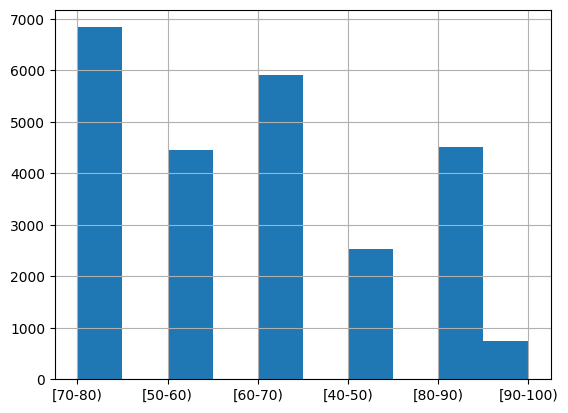

In [50]:
external_data.age.hist()

<Axes: >

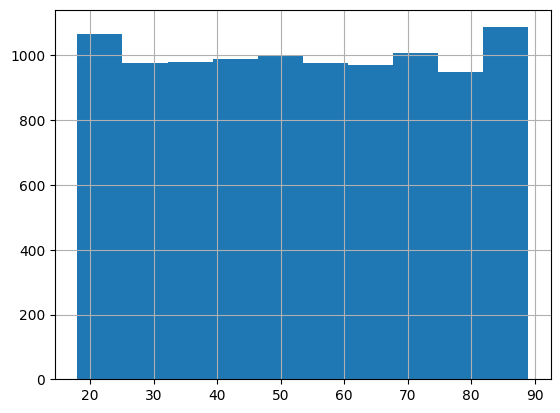

In [51]:
medical_data.Age.hist()

In [52]:
#External data is 40-99, Medical data is 18-89, make both between 40-89
medical_data = medical_data[(medical_data['Age'] >= 40) & (medical_data['Age'] <= 89)]

In [53]:
#Create age buckets in medical_data - Cite "https://dfrieds.com/data-analysis/bin-values-python-pandas.html#create-new-column-of-age_bins-via-defining-bin-edges"
medical_data['age_bins'] = pd.cut(x = medical_data['Age'], right= False, bins = [40, 50, 60, 70, 80, 90])

In [54]:
#Match bin labels - https://realpython.com/python-zip-function/
bin_labels = [f"[{left}-{right})" for left, right in zip(medical_data['age_bins'].apply(lambda x: x.left), medical_data['age_bins'].apply(lambda x: x.right))]

In [55]:
# Assign new labels to the bins
medical_data['age_bins'] = bin_labels

medical_data["age_bins"].value_counts()

age_bins
[70-80)    1426
[40-50)    1425
[50-60)    1408
[60-70)    1382
[80-90)    1334
Name: count, dtype: int64

In [56]:
#Limit external data to end at 89 too, drop 90-99 bucket
external_data = external_data[external_data['age'] != "[90-100)"]
external_data.age.value_counts()

age
[70-80)    6837
[60-70)    5913
[80-90)    4516
[50-60)    4452
[40-50)    2532
Name: count, dtype: int64

In [57]:
#Modify Diabetes and ReAdmis from medical_data to be boolean
medical_data['Diabetes'] = medical_data['Diabetes'].replace({"Yes": 1, "No": 0})
medical_data['ReAdmis'] = medical_data['ReAdmis'].replace({"Yes": 1, "No": 0})

medical_data['Diabetes'].value_counts()

C:\Users\matth\AppData\Local\Temp\ipykernel_30516\4127478430.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  medical_data['Diabetes'] = medical_data['Diabetes'].replace({"Yes": 1, "No": 0})
C:\Users\matth\AppData\Local\Temp\ipykernel_30516\4127478430.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  medical_data['ReAdmis'] = medical_data['ReAdmis'].replace({"Yes": 1, "No": 0})


Diabetes
0    5051
1    1924
Name: count, dtype: int64

In [58]:
external_data['Diabetes'].value_counts()

Diabetes
0    15644
1     8606
Name: count, dtype: int64

In [59]:
#Modify medical_data initial_days to match external_data's time_in_hospital
medical_data['Initial_days'] = medical_data['Initial_days'].astype(int)

In [60]:
#Add a source column to both external data and medical data
medical_data['Data Source'] = 'Internal data'
external_data['Data Source'] = 'External data'

In [61]:
#Only keep matching columns
external_columns_to_keep = ['age', 'time_in_hospital', 'readmitted', 'Diabetes', 'Data Source']
internal_columns_to_keep = ['age_bins', 'Initial_days', 'ReAdmis', 'Diabetes', 'Data Source']

external_data = external_data[external_columns_to_keep]
medical_data = medical_data[internal_columns_to_keep]

In [62]:
#Change external data column names to match medical data
external_data.rename(columns={'age': 'age_bins', 'time_in_hospital': 'Initial_days', 'readmitted': 'ReAdmis'}, inplace=True)

In [63]:
#Output cleaned external data
external_data.to_csv('cleaned_external_data.csv', index=False)

In [64]:
#Output cleaned medical data
medical_data.to_csv('cleaned_medical_data.csv', index=False)

In [65]:
#Append the external data to the internal data now that we have our Source Data column
medical_data['age_bins'] = medical_data['age_bins'].astype(object)

combined_df = pd.concat([medical_data, external_data], ignore_index=True)

In [66]:
#Output data set to use in Tableau
combined_df.to_csv('cleaned_combined_data.csv', index=False)

#### 2. Provide step-by-step instructions to guide users through the dashboard installation.

Because the dashboard is published to Tableau Public, no installatation is needed. Rather, the dashboard can simply be accessed by following the below link:
    
https://public.tableau.com/app/profile/matthew.helbig/viz/D210PerformanceAssessment_17081151912580/Story1

#### 3. Provide instructions to help users navigate the dashboard.

Regarding dashboard navigation, there are four tabs in the presentation, each presenting different insights and takeaways. The first tab, which can be accessed by clicking on the tab titled, "Age Distribution and Stay Length", includes graphics pertaining to age distribution and stay length. Clicking on "External System" for Age Distribution will segment the data to include only results from the external hospital system. Similarly, clicking on "WGU System" will segment the data to include only results from the WGU hospital system. The same can be done by clicking on the various ages (40-50 years old, etc) to segment by age bins. Stay length can also be segmented by the patients who had visits lasting a particular day by clicking on the bar representing that day. Clicking the orange bar will return the results for the WGU system patients for that day, while clicking on the blue bar will return results for the external hospital system patients. Holding the control key while clicking will allow the user to select both WGU patients and external patients for a given day by clicking both the orange and blue bar for a given day. Additionally, the data can be segmented by using the Diabetic and Readmitted filters in the top right corner.

The second tab in the presentation is the Readmission and Diabetes Status tab, which can also be accessed by clicking on the tab name. This tab contains pie charts for Readmission and Diabetes status. From here, users can segment the data by whether the patient was readmitted as it pertains to diabetes status, as well as diabetes status as it pertains to readmission percentage. Holding the control key and selecting the orange slices for Readmission under External System and WGU System will create a group of patients who were readmitted. This impacts the pie charts under Diabetes Status, as these percentages now pertain only for patients who have been readmitted. The same can be done for patients who were not readmitted by selecting the blue slices for Readmission. The same can be done for readmission by diabetes status by control-clicking the orange and blue slices under Diabetes Status. Additionally, both of these graphics can be filtered by a combinations of age bins as well as the number of the patient's days of initial visit.

Clicking on the "Readmission and Stay Length KPIs" tab shows you the Readmission by Diabetic Status and Average Stay Length by Age KPIs. These are not interactable and serve more of a fact-telling purpose.

Clicking on "Results and Insights" brings you to the key results and actionable insights, which can be read for informational purposes.

## Part 2: Storytelling with Data

### B. Provide a link to a Panopto multimedia presentation in which you tell a story about the data to an audience of data analytics peers. Your presentation should implement elements of effective storytelling and include *each* of the following elements:

#### - An introduction of yourself and your background
#### - A summary of *both* chosen data sets and the context in which they occur
#### - An outline of key results from your analysis of the two data sets
#### - Two different data representations to serve as supporting evidence for your results
#### - A summary of actionable insights based on your results

Please see the Panopto video that has submitted as part of this performance assessment.

## Part 3: Reflection Paper

### C. Write a reflection paper to demonstrate your understanding of data representation and reporting by doing the following:

#### 1. Explain how the purpose and function of your dashboard align with the needs outlined in the data dictionary associated with your chosen data set.

The chosen data set for this performance assessment is the Medical Data data set. The data dictionary for this data set indicates that the needs pertain primarily to patient readmission. Additionally, it is asked that a dashboard be built to allow for exploration of data, trend identification, and comparison of metrics.

As it is asked to determine whether readmission is a problem for this chain of hospitals, it would be helpful to compare the WGU Hospitals' readmission data to data from a different source. This dashboard facilitates this comparison by providing data similar to the WGU data, just from an outside source. While there are certainly many valuable conclusions that can be drawn from data exploration and trend identification within only the WGU data, the addition of the outside data for comparison will ideally help to strengthen the validity of any identified trends, as well as allow for greater exploration and cross-comparison of various metrics.

In the past courses, the primary focus of the Medical Data data set was concerning patient readmission. Conclusions and recommendations were made based on analysis of only the Medical Data data set. The inclusion of a comparable outside data set allows for those conclusions and recommendations to be tested and validated even further. If there are any glaring disparities between the internal and external data, these can be highlighted and assessed. Once disparities are understood, the specific disparities can be used to compare populations as well as potentialy identify any methods used to reduce readmission. 

#### 2. Explain how the variables in the additional data set enhance the insights that can be drawn from the data set you chose from the provided options.

The data set I chose from the provided options was the Medical Data data set. This data set is primarily concerned with patient readmission. The variables in the additional data set enhance the insights than can be drawn from the Medical Data data set because the external data set is also primarily concerned with the readmission of patients. Both data sets having the same primary focus should provide a solid foundation for any comparative analysis between the data sets.

In addition to the primary focus of the data sets being the same, there were several variables that were shared between the two data sets. Some of these variables exist in the raw data, while others required the Python data preparation steps noted above to ensure that the variables could be compared properly. The variables in both data sets are "Age Bins", "Initial Days", "Readmission", "Diabetes Status", and "Data Source." 

"Data Source" is a useful variable because it allows us to easily compare any insights between the internal hospital data and the external hospital data. The additional four variables are also incredibly useful for analyzing patient readmission. "Readmission" allows us to determine whether the patient was readmitted, and this readmission status can be further broken down by age, stay length, and Diabetes status. 

In short, the variables in the additional data set enhance the insights drawn in that they allow us to see if the results from the WGU hospital data are consistent with the results from the external hospital data. If the results are comparable, it would logically make sense that the conclusions and best practices from the WGU data alone could be more broadly applied going forward. Conversely, if the two populations vary wildly, it would benefit the organization to understand where the variations are and what could potentially be causing them.

#### 3. Explain two different data representations from your dashboard and how executive leaders can use them to support decision-making.

1) The first data representation from the dashboard that executive leaders can use to support decision-making is the Age Distribution table. Executive leaders can use this representation to identify the difference in spread for Age Bins between the WGU Hospital data and the external hospital data. From the table, we can clearly see that the WGU data is more consistently spread across the age bins, while the external data has the majority of its instances in the 60-80 Age Range. 

This cross-data deviation indicates that any conclusions made from one data set might not universally apply to the other data set due to the differences in proportions by age. For example, patients between 40-50 Years Old are overrepresented in the WGU Hospital data compared to the external hospital data. Similarly, patients between 70-80 Years Old are overrepresented in the external hospital data compared to the WGU Hospital data.

If a third data set with similar characteristics could be located or compiled, the disparity in distribution could be assessed to determine which of the two current data sets better represent the overall population distribution. Preventing that, the organization could break the data down by specific age bins when performing any analyses or making any conclusions. By ensuring that internal data patients aged between 40-50 are compared only to external data patients aged between 40-50, the organization would be better shielded against an issue where suboptimal decisions are being made to benefit a separate and overrepresented age group.



2) The second data representation from the dashboard that executive leaders can use to support decision-making is the Diabetes Status pie chart. From an initial look at the pie charts for external hospital data and WGU hospital data, we can see a disparity between the rates of Diabetic patients in the sample. WGU hospital data is roughly 28% Diabetic while the external hospital data is approximately 35% diabetic. 

This creates at least two implications for decision makers that should be addressed. The first potential implication is that there is some aspect of the WGU Hospital's treatment process that is limiting diabetes diagnoses in its patients. This implication being true would have massive benefits for both the WGU Hospital System as well as its patients. In order to evaluate whether this implication was true, additional comparable data sets could be located or compiled in order to determine how significant the current disparity may be.

The second implication is that there is some currently uncaptured variable or combination of variables that is causing this disparity in diabetes rates. This can potentially be mitigated in this instance by using the "Initial days" and "Age Bins" interactive controls to group the data by these variables to detect any major differences. However, the greater implication here is that a variable such as "Location" could be affecting the results. The data dictionary for this data notes that the WGU hospital chain has patients in almost every US state. Unfortunately, the external data did not have location information. As the rate of diabetes diagnoses differs by location (https://www.cdc.gov/diabetes/data/center/slides.html), it would be advisable to include location data or ensure that similar counties are being compared before fully accepting the first implication. Additionally, there could be additional valuable implications that present themselves when drilling down into the data.

#### 4. Explain two interactive controls in your dashboard and how *each* enables the user to modify the presentation of the data.

1) The first interactive control in the dashboard that enables the user to modify the presentation of the data is the "Readmitted" filter for Age Distribution and Stay Length. The "Readmitted" filter allows the user to break the data even further down by choosing whether the patient was readmitted or not (as well as being able to select all patients). Alternating between the patients that were readmitted and those that were not readmitted, insights begin to present themselves in the graphics for Age and Stay Length. 

For example, in the external hospital system, patients over 70 represent roughly 50% of all readmitted patients compared to 45% of all non-readmitted patients. Compare that to the WGU hospital system, where the numbers are roughly 41% and 40%, respectively. Just from the Readmission filter, we are already able to see a potentially actionable insight that could indicate that the WGU system excels at avoiding elderly patient readmission relative to other systems.

In the same vein, we can analyze the Stay Length graphic while toggling the Readmission filter. Immediately, we notice that there are disparities between each data set's stay length by readmission status. The external hospital data appears to have relatively consistent distribution of stay length between readmission statuses, while the WGU Hospital system sees that those readmitted tend to be those who had a longer initial stay length. By allowing for the modification of the presentation of the data, the Readmitted filter can provide quick and catchy insights.



2) The second interactive control in the dashboard that enables the user to modify the presentation of the data is the "Age Bins" filter for Readmission and Diabetes Status. The "Age Bins" filter allows the user to select any combination of age bins in order to identify any age-related trends in readmission as well as diabetes status. Clicking through and comparing the available Age Bins, an interesting trend begins to form. In the WGU Hospital data, diabetes rates are relatively consistent across all of the age bins. In the external hospital data, however, the rate of diabetes patients is highest amongst the youngest age group, and tends to gradually decrease as the age groups get older. This provides a quick launching point for a new insight or takeaway regarding age/diabetes interaction.

#### 5. Describe how you built your dashboard to be accessible for individuals with colorblindness.

Building the dashboard to be accessible for individuals with colorblindness can be tricky. Luckily, Tableau has published a blog entitled, "5 Tips on Designing Colorblind Friendly Visualizations" (https://www.tableau.com/blog/examining-data-viz-rules-dont-use-red-green-together).

There are a variety of helpful tips in this blog, all of which can be used to ensure that the dashboard is accessible for colorblind individuals. In my dashboard, there were two primary focuses. The first pertains to the usage of blue and green together in the Age Distribution table and Readmission by Diabetic Status KPI. Both of these graphics utilize blue and green to color pertinent data. In order to ensure dashboard accessibility, the light and dark aspects of those colors were prioritized. This way, even if the specific colors themselves become a little murky, the light-dark contrast will still be able to provide insight to the audience.

The second focus was to use the built-in colorblind-friendly palette whenever possible. Stay Length, Readmission, and Diabetes status all utlized this palette, ensuring that the quick insights provided by these graphics were as apparent as possible to all audiences. Additionally, toolkits were designed with a focus on providing as much concise information as possible. This ensures that, if there are any color-based confusions, the toolkit can ideally clear up those confusions. 

#### 6. Explain how *two* data representations in your presentation support the story you wanted to tell.

1) The first data representation in the presentation that supports the story I wanted to tell is the KPI titled "Percent of Readmission by Diabetic Status." This is a table that shows the disparity in readmission for diabetics and non-diabetics as well as the readmission disparity between the WGU Hospital System and the external hospital system. Interestingly, this KPI shows that both the WGU Hospital system and the external hospital system had lower rates of readmission for diabetics compared to non-diabetics. Additionally, the rates of readmission are relatively similar for diabetics and non-diabetics in each population.

The question of why diabetics have a lower readmission rate than non-diabetics (as well as why diabetes does not seem on its own to impact readmission) is worth a deeper look, however the main takeaway from this data representation is the disparity in overall readmission between the WGU Hospital system and the external hospital system. Overall, WGU readmitted between 36 and 37 percent of all patients, while the external hospital system readmitted between 46 and 47 percent of all patients. As the focus is on reducing readmissions, this readmission rate for WGU should be worth acknowledging. Overall, this data representation helps tell the story that WGU, at least compared to this comparable system, is succeeding at limiting readmissions. Additional data is likely needed in order to determine which factors are responsible for the lowered readmission rate, but this represents a solid springboard for actions.


2) The second data representation in the presentation that supports the story I wanted to tell is the KPI titled "Average Stay Length by Age." This data representation has two main takeaways. Beginning with the less impactful takeaway, it is interesting to note that average stay length consistently increases in the external data set as the patients get older, however we do not see a similar progression in the WGU Hospital data. Based on this, it is worth looking into what treatment styles are being offered to elderly patients, as well as what styles other hospitals use. If there is some technique that WGU Hospitals are using that other systems are not, then it could be that this technique is effective at reducing stay length.

The primary story that stands out from this data representation is the significant difference in stay length between the WGU Hospital data and the external hospital data. While the overall goal is to reduce readmissions and avoid excessive readmission penalties, it appears based on this data that the strategy for avoiding readmission may be misguided. While it is true, as noted in the first data representation, that the WGU Hospital system has a readmission rate of 36-37% compared to the external hospital system's readmission rate of 46-47%, if this is coming at the cost of extensive initial stays then it does not seem like this is a cost-effective strategy for avoiding monetary penalties.

For each age group, the WGU Hospital system kept their patients in the hospital for their initial visit approximately one month longer than the external hospital system did. Each night that a patient is kept in the hospital when they may not need to be is a night that costs the patient, as well as the hospital, money. Based on the significant stay length disparity, it appears that the WGU Hospital system is being overly safe and hesitant to discharge patients. An analysis of stay length across different reasons for visit could serve well to identify which, if any, reasons for visiting are predominantly responsible for the lengthy initial visit lengths.

#### 7. Explain how you used audience analysis to adapt the message in your presentation.

The University of Pittsburgh states that “Audience analysis involves identifying the audience and adapting a speech to their interests, level of understanding, attitudes, and beliefs” (https://www.comm.pitt.edu/oral-comm-lab/audience-analysis). 

The data dictionary states that the audience is comprised of two groups: executive leaders and data analytics peers. Presenting to two varying groups at the same time can present a challenge. However, utilizing a variety of presentation styles can allow for all audiences to have the message catered to them.

The executive leaders audience is comprised of the Senior Vice President of Hospital Operations (SVP), Vice President of Research (VP), and Panel of Regional Vice Presidents (Regional VPs). It is noted that these leaders are responsible for new initiatives, identifying patterns, driving improvements, and executing policies, among others. Given this information, the information provided to this audience should be easily interpreted while remaining broadly applicable. For instance, the Age Distribution graphic and Stay Length graphic both present information in a way that can be quickly understood while also making it obvious from the get-go where the primary areas of focus should be. In terms of presenting to the executive leaders audience, I aimed to present the data in a way that these leaders could easily explain and delegate any and all tasks that resulted from the conclusions this presentation made.

In addition to the executive leaders audience, this presentation has also been adapted for an audience of my data analytics peers. This audience has a greater domain knowledge than the executive leaders audience, but is also likely to be less interested in broad stroke conclusions. In order to adapt the presentation to an audience of my peers, I sought to provide as much information as possible, while also ensuring that there were enough ways to segment the data for any curious analyst to draw unique conclusions. This is evident in the Age Distribution graphic as well, with numerical information as well as two filters available in addition to the conditionally colored cells. When I have new data presented to me, I always try to find as many interesting relationships as possible, in search of some connection that no one has made before. For this audience, the eye-catching graphics are still important, they just pale in comparison to the value of the numbers and the methods that went into producing those numbers.   

#### 8. Describe how you designed your presentation for universal access by all audiences.

I designed my presentation for universal access by all audiences in a variety of ways. The primary focus was on visuals, where I tried to use colors that would easily stand out. In addition to this allowing for quick understanding of the data, it allows for someone who may be visually impaired to have an easier time noticing which colors stand out. Additionally, the specific colors were chosen with colorblind users in mind, so that any differences between the colors could still be easily identified by all audiences.

Font size and size of the graphics were considered to ensure widespread readibility. It may be tempting to try to cram as much information into a visual or toolkit, but that can cause people who struggle with vision at times to potentially miss large swathes of the presentation's message. I attempted to design my presentation for universal access by making sure that as much quality, yet still readable, data was present.

Audiences can vary in terms of how people prefer to receive data. Some people may think more visually, while others may think more in terms of numbers. In order to have the desired story be clearly told to as wide of an audience as possible, I tried to present conclusions in a way that was visually appealing, yet still told a story with raw numbers.

Additionally, adapting a presentation for a universal audience involves understanding that an audience can be comprised of various levels of domain knowledge. What may seem like jargon to one person may be massively insightful to another, and so it is important to be as clear as possible with the story being told. For those who only need to take a cursory glance at the data and draw conclusions from that, quick visuals were prioritized. For those who wish to drill deeper into the data and explore various relationships, this option is also present.

#### 9. Explain two elements of effective storytelling that you implemented in your presentation and how *each* element was intended to engage the audience

In their article, "Data Storytelling: How to Effectively Tell a Story with Data," Harvard Business School identifies the three components to storytelling as Data, Narrative, and Visualizations (https://online.hbs.edu/blog/post/data-storytelling). The first element, data, involves thorough analysis of the data as well as presenting complete data. In order to implement this element of effective storytelling, I provided a variety of different breakdowns to present a complete picture. For example, being able to filter Age and Stay Length by Diabetes/Readmission Status, as well as filtering Readmission and Diabetes Status by the number of initial days and age bins, both allow for a complete understanding of the data. These breakdowns allow for a variety of interactions between the data, each of which can potentially provide specific and unique insight. Presenting a complete and interesting panel of data to an audience should serve to have them more engaged with the presentation.

The second element, narrative, involves communicating insights gleaned from the data, the context of the data, as well as any recommended actions. In a way, the narrative acts as the umbrella that every other aspect of the presentation falls under. Every action underneath the narrative serves to tell a different aspect of the narrative. By breaking down the data into various visualizations, as well as providing a variety of easily understood numbers, the narrative is created that there are simple insights from the data that can lead to meaningful results. The visuals grab the audience's attention, and while their attention is held, the numbers drive home the message.

### D. Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.

Audience analysis. Department of Communication. (n.d.). https://www.comm.pitt.edu/oral-comm-lab/audience-analysis 
    
Centers for Disease Control and Prevention. (2022, September 30). Diabetes and obesity maps. Centers for Disease Control and Prevention. https://www.cdc.gov/diabetes/data/center/slides.html 

Data storytelling: How to tell a story with data. Business Insights Blog. (2021, November 23). https://online.hbs.edu/blog/post/data-storytelling 

Friedman, D. (n.d.). Cut() method: Bin values into discrete intervals¶. cut() Method: Bin Values into Discrete Intervals - dan_friedman_learnings. https://dfrieds.com/data-analysis/bin-values-python-pandas.html#create-new-column-of-age_bins-via-defining-bin-edges 

Jeffrey Shaffer COO and VP of Information Technology and Analytics. (2016, April 20). 5 tips on designing colorblind-friendly visualizations. Tableau. https://www.tableau.com/blog/examining-data-viz-rules-dont-use-red-green-together 

Real Python. (2023, October 21). Using the python zip() function for parallel iteration. https://realpython.com/python-zip-function/ 

### E. Demonstrate professional communication in the content and presentation of your submission.

Thank you.